# Bitcoin Price Forecasting —  Data Preprocessing Pipeline

## Executive Summary

This notebook builds a complete preprocessing workflow for high-frequency Bitcoin price forecasting. The purpose of this stage is to transform raw BTC/USD minute-level market data into a clean, consistent, scaled, and model-ready format.

The workflow is designed around time-series best practices: the chronological order is preserved, missing timestamps are handled explicitly, feature engineering is performed before splitting, and scaling is fitted only on the training period to avoid future data leakage.

## Main Objectives

- Load and inspect raw minute-level BTC/USD data.
- Reconstruct a continuous one-minute timeline.
- Handle missing values in a controlled and explainable way.
- Engineer meaningful forecasting features from price, volume, and time information.
- Split the dataset chronologically into training, validation, and testing periods.
- Apply scaling safely using only training data statistics.
- Save reusable arrays and preprocessing artifacts for the modeling stage.

## Expected Outputs

The pipeline produces the following reusable files:

- `train_scaled.npy`
- `val_scaled.npy`
- `test_scaled.npy`
- `scaler.pkl`

These files can be loaded directly during model training, evaluation, or deployment preparation.


In [ ]:
# ============================================================
# Environment Setup and Configuration 
# ============================================================

import os
import pickle
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# ------------------------------------------------------------
# Project paths — Kaggle
# ------------------------------------------------------------
DATA_PATH = Path("/kaggle/input/datasets/krismihali/bitcoin/coinbaseUSD_1-min_data_2014-12-01_to_2019-01-09.csv")

DRIVE_PATH = Path("/kaggle/working/BitcoinProject")
DRIVE_PATH.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Forecasting configuration
# ------------------------------------------------------------
WINDOW_SIZE = 1440      # 1440 minutes = 24 hours of historical context
HORIZON     = 60         # Predict the next minute
TRIM_START  = "2017-01-01"
TRAIN_END   = "2018-07-01"
VAL_END     = "2018-10-15"
CLOSE_IDX   = 0

FEATURES = [
    "Close",
    "volume_log",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos"
]

print("Environment ready")
print(f"Dataset path     : {DATA_PATH}")
print(f"Output directory : {DRIVE_PATH}")


Environment ready
Dataset path     : /kaggle/input/datasets/krismihali/bitcoin/coinbaseUSD_1-min_data_2014-12-01_to_2019-01-09.csv
Output directory : /kaggle/working/BitcoinProject


## Methodological Design Decisions

Several design choices are applied to make the preprocessing pipeline suitable for sequential machine learning models:

| Decision | Reason |
|---|---|
| Chronological splitting | Preserves the real order of the market and prevents future information from entering training. |
| Complete minute-level index | Makes missing timestamps visible instead of silently ignoring them. |
| Forward-fill strategy | Carries the last known market value forward, which is common for inactive or missing market intervals. |
| Cyclical time encoding | Represents hour and day patterns without creating artificial jumps between time boundaries. |
| Training-only scaling | Prevents validation and test data from influencing the fitted scaler. |

These choices make the processed dataset more reliable for GRU, LSTM, CNN-LSTM, or Transformer-based forecasting models.


## Preprocessing Pipeline Flow

The full preprocessing process follows this order:

1. Load the raw dataset.
2. Convert timestamps into a datetime index.
3. Reconstruct a complete one-minute timeline.
4. Fill missing values and remove invalid rows.
5. Trim the dataset to the selected period.
6. Engineer forecasting features.
7. Run quality checks and exploratory diagnostics.
8. Split data chronologically.
9. Fit the scaler only on training data.
10. Save processed arrays and preprocessing artifacts.

This structure keeps the pipeline transparent, reproducible, and easy to reuse.


## 1. Load and Reindex the Time Series

The raw CSV file is loaded into a pandas DataFrame and the Unix timestamp column is converted into a readable datetime format.

Because this is minute-level market data, the time index should ideally contain one row for every 60-second interval. Reindexing against a complete one-minute timeline makes missing timestamps explicit, which allows them to be handled consistently in the next step.


In [2]:
# ============================================================
# Load Raw Data and Build a Complete Minute-Level Index
# ============================================================
# The timestamp column is converted from Unix seconds to datetime.
# A complete 60-second index is then created so that missing
# minutes become visible as NaN rows.

print('Loading raw data...')
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'  Loaded: {len(df):,} rows')

df['datetime'] = pd.to_datetime(df['Timestamp'], unit='s')
df = df.set_index('datetime').sort_index()

full_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='60s'
)
df = df.reindex(full_index)

print(f'  Rows after reindex : {len(df):,}')
print(f'  NaN rows surfaced  : {df["Close"].isna().sum():,}')
print(f'  Date range         : {df.index.min()} → {df.index.max()}')
print('Reindex complete ')


Loading raw data...
  Loaded: 2,099,760 rows
  Rows after reindex : 2,158,114
  NaN rows surfaced  : 167,423
  Date range         : 2014-12-01 05:33:00 → 2019-01-07 22:06:00
Reindex complete 


## Dataset Integrity Check

Before applying transformations, the dataset is checked for temporal consistency and missing values. This step helps identify whether the time series contains irregular intervals, duplicated timestamps, or columns with incomplete information.


In [ ]:
# ============================================================
# Dataset Integrity Diagnostics
# ============================================================
# These checks provide a quick overview of the dataset quality
# before deeper preprocessing is applied.

print('Dataset shape:', df.shape)
print('
Missing values per column:')
print(df.isna().sum())

print('
Time index summary:')
print(f'  Start date : {df.index.min()}')
print(f'  End date   : {df.index.max()}')
print(f'  Total rows : {len(df):,}')

duplicate_timestamps = df.index.duplicated().sum()
print(f'  Duplicate timestamps: {duplicate_timestamps:,}')


## 2. Handle Missing Values with Forward-Fill

After reindexing, missing rows appear as `NaN` values. For financial time-series data, forward-fill is commonly used because it carries the most recent known market value into inactive or missing minutes.

Rows at the very beginning of the dataset that still have no valid previous value are removed after the fill operation.


In [3]:
# ============================================================
# Forward-Fill Missing Market Values
# ============================================================
# Forward-fill preserves the last available market observation
# and avoids leaving gaps in the time series.

nan_before = df['Close'].isna().sum()
df = df.ffill()
nan_after  = df['Close'].isna().sum()

df = df.dropna(subset=['Close'])

print(f'  NaN rows before ffill : {nan_before:,}')
print(f'  NaN rows after ffill  : {nan_after:,}')
print(f'  Rows after dropna     : {len(df):,}')
print('Forward-fill complete ')

  NaN rows before ffill : 167,423
  NaN rows after ffill  : 0
  Rows after dropna     : 2,158,114
Forward-fill complete 


## Missing-Value Validation

After forward-filling, the remaining missing values are reviewed. A clean preprocessing output should not contain missing values in the final feature columns used for modeling.


In [ ]:
# ============================================================
# Validate Missing Values After Filling
# ============================================================
# This confirms whether the forward-fill operation successfully
# handled missing observations in the main market variables.

print('Remaining missing values after cleaning:')
print(df.isna().sum())

if df.isna().sum().sum() == 0:
    print('
Validation passed: no missing values remain.')
else:
    print('
Warning: some missing values are still present and should be reviewed.')


## 3. Trim the Dataset to the Selected Period

The dataset is trimmed from `2017-01-01` onward. This keeps the modeling period focused on a denser and more reliable section of the series.

Removing earlier sparse regions helps reduce artificial flat segments that could be introduced by long forward-filled gaps.


In [4]:
# ============================================================
# Trim the Dataset to the Selected Forecasting Period
# ============================================================
# Keeping a cleaner and denser time period helps reduce noise
# introduced by long missing intervals in earlier data.

rows_before = len(df)
df = df[df.index >= TRIM_START]
rows_after  = len(df)

print(f'  Rows before trim : {rows_before:,}')
print(f'  Rows after trim  : {rows_after:,}')
print(f'  Rows removed     : {rows_before - rows_after:,}')
print(f'  Date range       : {df.index.min()} → {df.index.max()}')
print('Trim complete ')

  Rows before trim : 2,158,114
  Rows after trim  : 1,061,167
  Rows removed     : 1,096,947
  Date range       : 2017-01-01 00:00:00 → 2019-01-07 22:06:00
Trim complete 


## 4. Feature Engineering

A compact feature matrix is created for forecasting. The selected features capture both price behavior and time-based patterns.

The final feature set includes:

- **Close** — the main BTC/USD price signal and forecasting target.
- **volume_log** — logarithmic transformation of BTC volume to reduce skewness.
- **hour_sin / hour_cos** — cyclic representation of hour-of-day patterns.
- **dow_sin / dow_cos** — cyclic representation of day-of-week patterns.

Cyclic encodings are used instead of raw hour/day numbers because time features repeat naturally. For example, hour 23 and hour 0 are close in real time, even though their numeric values are far apart.


In [5]:
# ============================================================
# Create Forecasting Features
# ============================================================
# The feature matrix combines price, transformed volume,
# and cyclic time encodings for hourly and weekly patterns.

df['volume_log'] = np.log1p(df['Volume_(BTC)'])

hour = df.index.hour + df.index.minute / 60.0
df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * hour / 24)

dow = df.index.dayofweek
df['dow_sin'] = np.sin(2 * np.pi * dow / 7)
df['dow_cos'] = np.cos(2 * np.pi * dow / 7)

df = df[FEATURES]

print(f'  Feature columns : {FEATURES}')
print(f'  Shape           : {df.shape}')
print()
print(df.head(3))
print('Feature engineering complete ✓')

  Feature columns : ['Close', 'volume_log', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
  Shape           : (1061167, 6)

                      Close  volume_log  hour_sin  hour_cos   dow_sin  dow_cos
2017-01-01 00:00:00  973.35    1.138489  0.000000  1.000000 -0.781831  0.62349
2017-01-01 00:01:00  973.35    1.138489  0.004363  0.999990 -0.781831  0.62349
2017-01-01 00:02:00  973.35    1.138489  0.008727  0.999962 -0.781831  0.62349
Feature engineering complete ✓


## Additional Market Diagnostics

Although the final model input uses the selected feature matrix, additional diagnostic variables are useful for understanding market behavior. Log price and log returns are commonly used in financial analysis because they help describe relative price movement rather than only absolute price levels.


In [ ]:
# ============================================================
# Create Diagnostic Financial Variables
# ============================================================
# These variables are used for analysis and validation only.
# They help evaluate how price changes behave over time.

df['log_close'] = np.log(df['Close'])
df['log_return'] = df['log_close'].diff()

print('Diagnostic variables created:')
print(df[['Close', 'log_close', 'log_return']].head())


## Visual Diagnostic: Price and Log Returns

The closing price shows the overall BTC/USD market trend, while log returns highlight short-term movement and volatility. This comparison helps confirm why financial time-series forecasting often requires careful preprocessing.


In [ ]:
# ============================================================
# Visualize Price Level and Log Returns
# ============================================================
# The first plot shows the absolute BTC price.
# The second plot shows relative movement through log returns.

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(df.index, df['Close'], linewidth=0.4)
axes[0].set_title('BTC/USD Closing Price Over Time')
axes[0].set_ylabel('Price (USD)')

axes[1].plot(df.index, df['log_return'], linewidth=0.3)
axes[1].set_title('BTC/USD Log Returns Over Time')
axes[1].set_ylabel('Log return')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()


## Feature Quality Check

The engineered feature matrix is reviewed before splitting. This confirms that the expected columns exist, that no invalid values were introduced, and that each feature has a reasonable numerical range.


In [ ]:
# ============================================================
# Validate Engineered Features
# ============================================================
# This check ensures that the model input columns are present,
# numeric, and free of missing values before the split stage.

print('Selected features:')
print(FEATURES)

print('
Feature summary statistics:')
print(df[FEATURES].describe().T)

print('
Missing values in selected features:')
print(df[FEATURES].isna().sum())


## 5. Chronological Train / Validation / Test Split

The dataset is split strictly by date. No shuffling is applied because shuffling a time series would mix past and future observations and create data leakage.

| Split | Period | Purpose |
|---|---|---|
| Train | From `2017-01-01` to before `2018-07-01` | Used to fit the model |
| Validation | From `2018-07-01` to before `2018-10-15` | Used for tuning and monitoring performance |
| Test | From `2018-10-15` onward | Used for final unbiased evaluation |


In [6]:
# ============================================================
# Split Data Chronologically
# ============================================================
# Time-series data must be split by date to preserve causal order.
# The model trains on the past and is validated/tested on later periods.

train_df = df[df.index <  TRAIN_END]
val_df   = df[(df.index >= TRAIN_END) & (df.index < VAL_END)]
test_df  = df[df.index >= VAL_END]

print(f'  Train : {len(train_df):,} rows  ({train_df.index.min().date()} → {train_df.index.max().date()})')
print(f'  Val   : {len(val_df):,} rows  ({val_df.index.min().date()} → {val_df.index.max().date()})')
print(f'  Test  : {len(test_df):,} rows  ({test_df.index.min().date()} → {test_df.index.max().date()})')
print()
print(f'  Train : {len(train_df)/len(df)*100:.1f}%')
print(f'  Val   : {len(val_df)/len(df)*100:.1f}%')
print(f'  Test  : {len(test_df)/len(df)*100:.1f}%')
print('Split complete ')

  Train : 786,240 rows  (2017-01-01 → 2018-06-30)
  Val   : 152,640 rows  (2018-07-01 → 2018-10-14)
  Test  : 122,287 rows  (2018-10-15 → 2019-01-07)

  Train : 74.1%
  Val   : 14.4%
  Test  : 11.5%
Split complete 


## Split Proportion Review

A forecasting model depends heavily on how the historical timeline is divided. The following check summarizes the relative size of each split and confirms that each period contains enough observations for training, validation, and final evaluation.


In [ ]:
# ============================================================
# Review Split Sizes and Proportions
# ============================================================
# This creates a compact summary of how much data is assigned
# to each chronological split.

split_summary = pd.DataFrame({
    'split': ['Train', 'Validation', 'Test'],
    'rows': [len(train_df), len(val_df), len(test_df)]
})
split_summary['percentage'] = 100 * split_summary['rows'] / split_summary['rows'].sum()

print(split_summary)

plt.figure(figsize=(8, 4))
plt.bar(split_summary['split'], split_summary['rows'])
plt.title('Number of Observations per Dataset Split')
plt.ylabel('Rows')
plt.xlabel('Split')
plt.show()


## 6. Scale the Features and Save the Scaler

`MinMaxScaler` is fitted only on the training data. The validation and test sets are transformed using the same fitted scaler.

This is important because fitting the scaler on the full dataset would expose future price ranges to the training process, causing data leakage.

The fitted scaler is saved as `scaler.pkl` so that future predictions can be converted back from scaled values to USD.


In [7]:
# ============================================================
# Fit Scaler on Training Data Only
# ============================================================
# The scaler is fitted only on training values to prevent information
# from validation/test periods from leaking into the training process.

scaler      = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df.values)
val_scaled   = scaler.transform(val_df.values)
test_scaled  = scaler.transform(test_df.values)

scaler_path = os.path.join(DRIVE_PATH, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f'  Scaler fitted on  : {len(train_df):,} rows')
print(f'  Train scaled range: [{train_scaled.min():.4f}, {train_scaled.max():.4f}]')
print(f'  Val scaled range  : [{val_scaled.min():.4f}, {val_scaled.max():.4f}]')
print(f'  Test scaled range : [{test_scaled.min():.4f}, {test_scaled.max():.4f}]')
print(f'  Scaler saved  {scaler_path}')
print('Scaling complete ')

  Scaler fitted on  : 786,240 rows
  Train scaled range: [0.0000, 1.0000]
  Val scaled range  : [0.0000, 1.0000]
  Test scaled range : [0.0000, 1.0000]
  Scaler saved  /content/drive/MyDrive/BitcoinProject/scaler.pkl
Scaling complete 


## Scaling Validation

After scaling, the transformed arrays are checked to confirm their shapes and numerical ranges. The training set should be bounded according to the scaler fit, while validation and test values may occasionally fall slightly outside the training range if market behavior changes.


In [ ]:
# ============================================================
# Validate Scaled Arrays
# ============================================================
# This diagnostic confirms that the scaling transformation produced
# arrays with the expected dimensions and numerical behavior.

scaled_summary = pd.DataFrame({
    'split': ['Train', 'Validation', 'Test'],
    'shape': [train_scaled.shape, val_scaled.shape, test_scaled.shape],
    'min_value': [train_scaled.min(), val_scaled.min(), test_scaled.min()],
    'max_value': [train_scaled.max(), val_scaled.max(), test_scaled.max()]
})

print(scaled_summary)


## 7. Visualize the Processed Splits

The plots below provide a visual check of the chronological train, validation, and test split.

The first plot shows the original BTC closing price in USD across each split. The second plot shows the scaled close-price values, confirming that the scaler has been applied consistently.


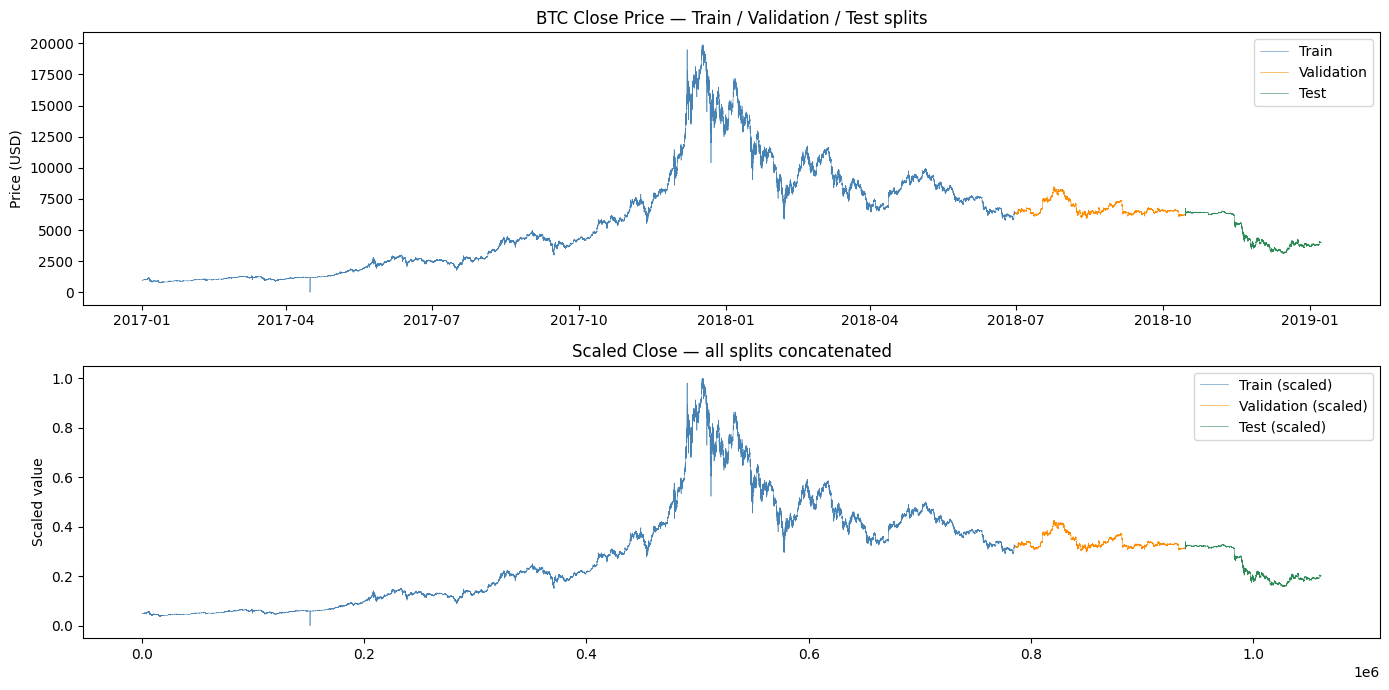

In [8]:
# ============================================================
# Plot Original and Scaled Split Distributions
# ============================================================
# These visualizations confirm that each split occupies a distinct
# time interval and that scaling has been applied consistently.

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(train_df.index, train_df['Close'], color='steelblue',
             linewidth=0.4, label='Train')
axes[0].plot(val_df.index,   val_df['Close'],   color='darkorange',
             linewidth=0.4, label='Validation')
axes[0].plot(test_df.index,  test_df['Close'],  color='seagreen',
             linewidth=0.4, label='Test')
axes[0].set_title('BTC Close Price — Train / Validation / Test splits')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

axes[1].plot(train_scaled[:, CLOSE_IDX], color='steelblue',
             linewidth=0.4, label='Train (scaled)')
axes[1].plot(range(len(train_scaled),
                   len(train_scaled) + len(val_scaled)),
             val_scaled[:, CLOSE_IDX],
             color='darkorange', linewidth=0.4, label='Validation (scaled)')
axes[1].plot(range(len(train_scaled) + len(val_scaled),
                   len(train_scaled) + len(val_scaled) + len(test_scaled)),
             test_scaled[:, CLOSE_IDX],
             color='seagreen', linewidth=0.4, label='Test (scaled)')
axes[1].set_title('Scaled Close — all splits concatenated')
axes[1].set_ylabel('Scaled value')
axes[1].legend()

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'splits.png', dpi=150, bbox_inches='tight')
plt.show()

## Practical Notes and Potential Pitfalls

The following issues are important when working with financial time-series data:

- **Data leakage:** The scaler must never be fitted on validation or test data.
- **Incorrect timestamp alignment:** A shifted target can make the model learn the wrong forecasting task.
- **Missing intervals:** Large gaps can distort the continuity of the sequence.
- **Non-stationary market behavior:** Bitcoin price dynamics change over time, so evaluation on a future test period is essential.
- **Overfitting risk:** Deep learning models may memorize short-term patterns if validation is not monitored carefully.

These checks reduce the risk of building a model that performs well during development but fails on unseen data.


## 8. Save the Preprocessed Arrays

The processed arrays are saved as `.npy` files. These files are lightweight, fast to load, and ready to be used directly in the modeling stage.

Saving the arrays also makes the workflow reproducible because the same processed data can be reused without repeating the full preprocessing pipeline.


In [9]:
# ============================================================
# Save Final Preprocessed Outputs
# ============================================================
# The scaled arrays are saved for direct use in model training.

np.save(DRIVE_PATH + 'train_scaled.npy', train_scaled)
np.save(DRIVE_PATH + 'val_scaled.npy',   val_scaled)
np.save(DRIVE_PATH + 'test_scaled.npy',  test_scaled)

print(f'  train_scaled.npy  {train_scaled.shape}')
print(f'  val_scaled.npy    {val_scaled.shape}')
print(f'  test_scaled.npy   {test_scaled.shape}')
print(f'  scaler.pkl        already saved in Step 6')
print()
print('Preprocessing complete ')

  train_scaled.npy  (786240, 6)
  val_scaled.npy    (152640, 6)
  test_scaled.npy   (122287, 6)
  scaler.pkl        already saved in Step 6

Preprocessing complete 


## Final Conclusion

The preprocessing stage is complete. The raw BTC/USD minute-level dataset has been converted into clean, scaled, and chronologically separated arrays suitable for sequential forecasting models.

The final outputs preserve the temporal structure of the market data and avoid data leakage by fitting preprocessing transformations only on the training period.

## Recommended Next Steps

- Build a GRU, LSTM, CNN-LSTM, or Transformer-based forecasting model.
- Train the model using `train_scaled.npy` and monitor performance on `val_scaled.npy`.
- Evaluate final performance on `test_scaled.npy` using MAE, RMSE, and visual actual-vs-predicted comparisons.
- Save the trained model together with the scaler for future inference or web deployment.
